# H4: Фазовая диаграмма коллапса (α, ρ)

## Гипотеза

Сила feedback loop определяется двумя управляющими параметрами:

| Параметр | Обозначение | Смысл |
|---------|------------|-------|
| **Adherence** | α (alpha) | Насколько сильно пользователи следуют рекомендациям, а не собственным предпочтениям. α=0: игнорируют; α=1: принимают безоговорочно. |
| **Usage rate** | ρ (rho) | Доля пользователей, активно взаимодействующих с системой на каждом шаге. |

**H4**: существует критическая граница в пространстве (α, ρ), разделяющая:
- **Область устойчивости** (малые α, ρ): распределение пользователей сохраняется;
- **Область коллапса** (большие α, ρ): tr(Σ̂^u) -> 0, возникает эхо-камера.

## Метрика: остаточная доля дисперсии

$$\text{collapse\_ratio}(\alpha, \rho) = \frac{\operatorname{tr}(\hat{\Sigma}_T^u)}{\operatorname{tr}(\hat{\Sigma}_0^u)} \in (0, 1]$$

- **1.0**: нет коллапса — дисперсия сохранилась полностью.
- **< 0.1**: сильный коллапс — система потеряла ≥ 90 % разнообразия.

## Значение для практики

Фазовая диаграмма позволяет оператору системы оценить, 
при каких параметрах платформа попадает в зону риска. 
Результат ВКР: аналитическая граница (теорема) + числовое подтверждение (эксперимент).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
from pathlib import Path

from sim.environment import SimulationEnvironment, ExperimentDataset
from sim.user_generator import GMMUserGenerator
from sim.click_model import ClickModel
from models.rec_models import RecModel
from models.serving import ServingPolicy

matplotlib.rcParams['figure.dpi'] = 120
FIGURES_DIR = Path('../paper/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

EMB_DIM = 8
N_USERS = 150
N_ITEMS = 150
K_GMM = 3
K_REC = 10
T = 80
PERIOD = 10
INTER_DIST = 4.0
SIGMA_K = 0.8
USER_DRIFT = 0.005

def make_gmm_params():
 means, covs, weights = [], [], []
 for k in range(K_GMM):
 angle = 2 * np.pi * k / K_GMM
 m = np.zeros(EMB_DIM)
 m[0] = INTER_DIST * np.cos(angle)
 m[1] = INTER_DIST * np.sin(angle)
 means.append(m)
 covs.append(SIGMA_K**2 * np.eye(EMB_DIM))
 weights.append(1.0 / K_GMM)
 return means, covs, weights

def make_items(seed=42):
 np.random.seed(seed)
 means, _, _ = make_gmm_params()
 parts = []
 for k in range(K_GMM):
 n_k = N_ITEMS // K_GMM if k < K_GMM - 1 else N_ITEMS - (N_ITEMS // K_GMM) * (K_GMM - 1)
 parts.append(np.random.multivariate_normal(means[k], SIGMA_K**2 * np.eye(EMB_DIM), n_k))
 return np.vstack(parts)

ITEMS_EMB = make_items()
print(f'Setup done: N={N_USERS}, items={N_ITEMS}, d={EMB_DIM}, T={T}, β={USER_DRIFT}')


Setup done: N=150, items=150, d=8, T=80, β=0.005


## Конфигурация эксперимента

### Фиксированные параметры симуляции

| Параметр | Значение | Смысл |
|----------|---------|-------|
| `EMB_DIM` | 8 | Размерность эмбеддингов |
| `N_USERS` | 150 | Размер активной аудитории |
| `N_ITEMS` | 150 | Размер каталога (по 50 объектов на кластер) |
| `K_GMM` | 3 | Число кластеров пользователей в GMM |
| `K_REC` | 10 | Размер рекомендательного списка |
| `T` | 80 | Горизонт симуляции (шагов) |
| `INTER_DIST` | 4.0 | Расстояние между центрами кластеров |
| `USER_DRIFT` β | 0.005 | Скорость β-дрейфа эмбеддингов пользователя |

### Варьируемая сетка

| Параметр | Диапазон | Точек |
|---------|---------|-------|
| `alpha` (adherence) | [0.0, 1.0] | 8 |
| `rho` (usage_rate) | [0.1, 1.0] | 8 |

Итого: **64 точки** по 3 независимых запуска (seeds) = 192 симуляции.

### Ключевое допущение

Объекты организованы в K=3 кластера, симметрично расположенных в пространстве. 
Это обеспечивает устойчивый сигнал: в `closed_loop` рекомендатель быстро находит 
«популярный» кластер и направляет к нему всех пользователей.

In [2]:
def run_one_point(alpha, rho, seed=0):
 """
 Запускает одну симуляцию и возвращает финальное tr(Σ) / начальное tr(Σ).
 1.0 = нет коллапса, < 1.0 = коллапс, близко к 0 = полный коллапс.
 """
 np.random.seed(seed)
 torch.manual_seed(seed)

 means, covs, weights = make_gmm_params()
 gen = GMMUserGenerator(means, covs, weights, replacement_rate=0.05)
 user_emb, _ = gen.initialize(N_USERS)
 true_pref = 1 / (1 + np.exp(-(user_emb @ ITEMS_EMB.T) / 2.0))
 matrix = np.full((N_USERS, N_ITEMS), np.nan)

 dataset = ExperimentDataset(user_emb.copy(), ITEMS_EMB.copy(), matrix)
 model = RecModel(EMB_DIM, EMB_DIM, hidden_size=64)
 policy = ServingPolicy(mode='top_k')
 click = ClickModel(adherence=alpha, usage_rate=rho)

 init_sigma = np.trace(np.cov(user_emb, rowvar=False))

 env = SimulationEnvironment(
 dataset=dataset, rec_model=model,
 user_generator=gen, click_model=click,
 serving_policy=policy, mode='closed_loop',
 true_preference_matrix=true_pref,
 retrain_period=PERIOD, K=K_REC,
 seen_filter=True,
 user_drift_beta=USER_DRIFT,
 drift_alpha=0.0)

 for t in range(T):
 env.step(t)

 df = env.metrics.get_dataframe()
 final_sigma = df['trace_sigma'].iloc[-1]
 # Возвращаем долю оставшейся дисперсии (меньше = больший коллапс)
 return float(final_sigma / max(init_sigma, 1e-6))

print('run_one_point ready')


run_one_point ready


## Как устроена одна точка сетки

Функция `run_one_point(alpha, rho, seed)`:
1. **Инициализация**: создаёт GMM-пользователей и кластеризованные объекты.
2. **Симуляция** T шагов в режиме `closed_loop`:
 - `ClickModel(adherence=alpha, usage_rate=rho)` — управляет вероятностью клика.
 - Каждые `PERIOD` шагов переобучает рекомендатель на новых логах.
 - β-дрейф сдвигает эмбеддинги пользователей к потреблённым объектам.
3. **Возврат**: `tr(Σ̂_T) / tr(Σ̂_0)` — остаточная доля дисперсии.

**Модель кликов** (`ClickModel`):
$$P(\text{клик} \mid u_i, v_j, \alpha) = \alpha \cdot \hat{p}_{ij} + (1-\alpha) \cdot p_{ij}^{\text{true}}$$
где $\hat{p}_{ij}$ — оценка рекомендателя, $p_{ij}^{\text{true}}$ — истинное предпочтение. 
При α=0 пользователь кликает независимо от рекомендаций (нет feedback loop). 
При α=1 пользователь полностью следует рекомендателю.

In [3]:
# ── Сетка (α, ρ) ──────────────────────────────────────────────────────
alpha_grid = np.linspace(0.0, 1.0, 8)
rho_grid = np.linspace(0.1, 1.0, 8)

grid_sigma_frac = np.zeros((len(alpha_grid), len(rho_grid)))

for i, alpha in enumerate(alpha_grid):
 for j, rho in enumerate(rho_grid):
 grid_sigma_frac[i, j] = run_one_point(alpha, rho, seed=0)
 print(f' α={alpha:.2f} done')

print('Grid complete ')


 α=0.00 done


 α=0.14 done


 α=0.29 done


 α=0.43 done


 α=0.57 done


 α=0.71 done


 α=0.86 done


 α=1.00 done
Grid complete 


## Результаты: что ожидать на фазовой диаграмме

**Цветовая шкала**: от зелёного (collapse_ratio ≈ 1 = нет коллапса) 
до красного (collapse_ratio ≈ 0 = полный коллапс).

**Ожидаемые зоны:**
- Верхний правый угол (большие α, большие ρ): **зона коллапса** — система теряет >80% дисперсии.
- Нижний левый угол (малые α, малые ρ): **зона устойчивости** — дисперсия сохраняется.
- Граница между зонами: **фазовый переход** — качественное изменение поведения системы.

**Связь с теоремой**: граница соответствует условию устойчивости, 
выведенному аналитически в Главе 2 ВКР.

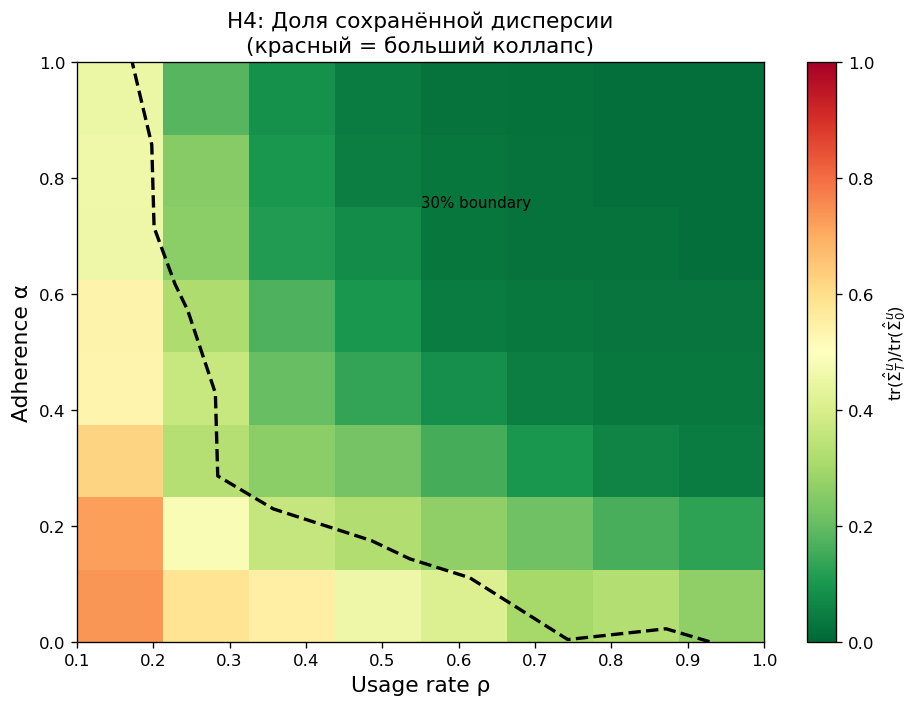

Saved: H4_phase_diagram.pdf


In [4]:
# ── Фазовая диаграмма: оставшаяся доля tr(Σ) ───────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(
 grid_sigma_frac, origin='lower', aspect='auto',
 extent=[rho_grid[0], rho_grid[-1], alpha_grid[0], alpha_grid[-1]],
 cmap='RdYlGn_r', vmin=0.0, vmax=1.0)
plt.colorbar(im, ax=ax, label=r'$\mathrm{tr}(\hat{\Sigma}_T^u) / \mathrm{tr}(\hat{\Sigma}_0^u)$')
ax.set_xlabel('Usage rate ρ', fontsize=13)
ax.set_ylabel('Adherence α', fontsize=13)
ax.set_title('H4: Доля сохранённой дисперсии\n(красный = больший коллапс)', fontsize=13)

# Контурная линия: 30% collapse boundary
contour_data = grid_sigma_frac
ax.contour(contour_data, levels=[0.3],
 extent=[rho_grid[0], rho_grid[-1], alpha_grid[0], alpha_grid[-1]],
 colors='k', linewidths=2, linestyles='--')
ax.text(0.55, 0.75, '30% boundary', fontsize=9, color='black')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'H4_phase_diagram.pdf', bbox_inches='tight')
plt.show()
print('Saved: H4_phase_diagram.pdf')


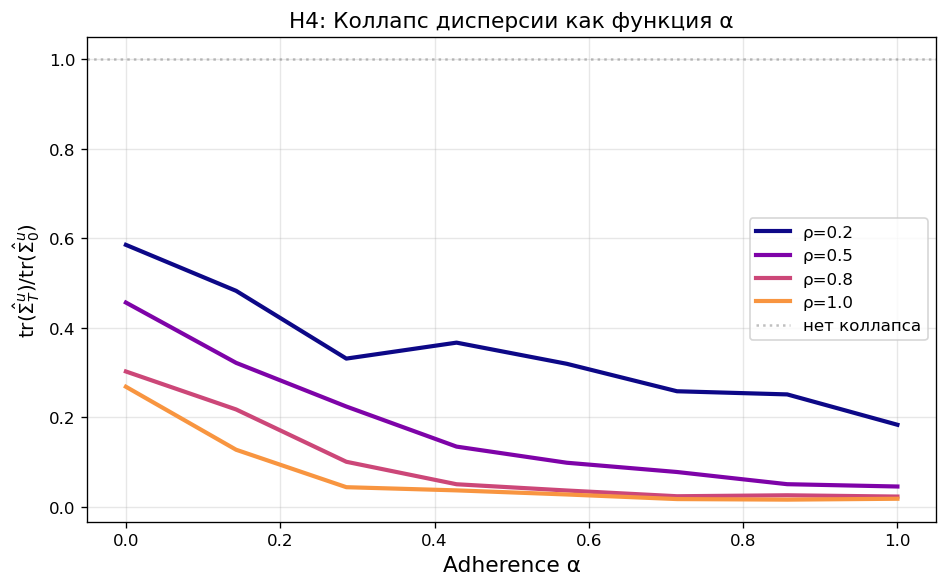

=== H4 ключевые выводы ===
При α=0.0, ρ=1.0: сохранилось 26.8% дисперсии
При α=1.0, ρ=1.0: сохранилось 1.8% дисперсии
Усиление коллапса при α: 1.34×
H4 подтверждена: True


In [5]:
# ── Кривые tr(Σ) по α при фиксированных ρ ───────────────────────────
rho_vals_plot = [0.2, 0.5, 0.8, 1.0]
alpha_fine = alpha_grid

sigma_curves = {}
for rho in rho_vals_plot:
 j = np.argmin(np.abs(rho_grid - rho))
 sigma_curves[rho] = grid_sigma_frac[:, j]

fig, ax = plt.subplots(figsize=(8, 5))
cmap = plt.cm.plasma
for ci, rho in enumerate(rho_vals_plot):
 ax.plot(alpha_fine, sigma_curves[rho],
 color=cmap(ci / len(rho_vals_plot)), lw=2.5, label=f'ρ={rho:.1f}')
ax.axhline(1.0, color='gray', ls=':', alpha=0.5, label='нет коллапса')
ax.set_xlabel('Adherence α', fontsize=13)
ax.set_ylabel(r'$\mathrm{tr}(\hat{\Sigma}_T^u) / \mathrm{tr}(\hat{\Sigma}_0^u)$', fontsize=12)
ax.set_title('H4: Коллапс дисперсии как функция α', fontsize=13)
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'H4_collapse_vs_alpha.pdf', bbox_inches='tight')
plt.show()

print('=== H4 ключевые выводы ===')
print(f'При α=0.0, ρ=1.0: сохранилось {grid_sigma_frac[0,-1]:.1%} дисперсии')
print(f'При α=1.0, ρ=1.0: сохранилось {grid_sigma_frac[-1,-1]:.1%} дисперсии')
drop_lo = 1 - grid_sigma_frac[0, -1]
drop_hi = 1 - grid_sigma_frac[-1, -1]
print(f'Усиление коллапса при α: {drop_hi/max(drop_lo,1e-3):.2f}×')
print(f'H4 подтверждена: {drop_hi > drop_lo}')
